In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 311_ServiceRequest_2010-present_DataDictionary Combined.csv to 311_ServiceRequest_2010-present_DataDictionary Combined (1).csv


In [ ]:
df = pd.read_csv("311_ServiceRequest_2010-present_DataDictionary Combined.csv")
df.head()

,Agency,Complaint Type,Descriptor,Additional_Details,Location_Type
0,Department for the Aging,Case Management Agency Complaint,NaN,NaN,Address Unknown
1,Department for the Aging,Case Management Agency Complaint,NaN,NaN,Senior Address
2,Department for the Aging,Elder Abuse,NaN,NaN,Senior Address
3,Department for the Aging,Eviction,Homebound Senior,NaN,Address Unknown
4,Department for the Aging,Eviction,Mobile Senior,NaN,Address Unknown


In [ ]:
print("Rows and columns:", df.shape)
print(df.columns.tolist())
df.info()

Rows and columns: (24028, 5)
['Agency', 'Complaint Type', 'Descriptor', 'Additional_Details', 'Location_Type']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24028 entries, 0 to 24027
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Agency              24028 non-null  object
 1   Complaint Type      24028 non-null  object
 2   Descriptor          23824 non-null  object
 3   Additional_Details  19930 non-null  object
 4   Location_Type       23868 non-null  object
dtypes: object(5)
memory usage: 938.7+ KB


In [ ]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['Agency',
 'Complaint Type',
 'Descriptor',
 'Additional_Details',
 'Location_Type']

In [ ]:
columns_to_keep = ['Agency', 'Complaint Type', 'Descriptor', 'Location_Type']

df = df[columns_to_keep]
df.head()

,Agency,Complaint Type,Descriptor,Location_Type
0,Department for the Aging,Case Management Agency Complaint,NaN,Address Unknown
1,Department for the Aging,Case Management Agency Complaint,NaN,Senior Address
2,Department for the Aging,Elder Abuse,NaN,Senior Address
3,Department for the Aging,Eviction,Homebound Senior,Address Unknown
4,Department for the Aging,Eviction,Mobile Senior,Address Unknown


In [ ]:
df = df.dropna(subset=['Agency', 'Complaint Type'])

df['Descriptor'] = df['Descriptor'].fillna('Not Listed')
df['Location_Type'] = df['Location_Type'].fillna('Not Listed')

df.shape

(24028, 4)

In [ ]:
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique Agencies',
        'Unique Complaint Types',
        'Unique Descriptors',
        'Unique Location Types'
    ],
    'Value': [
        len(df),
        df['Agency'].nunique(),
        df['Complaint Type'].nunique(),
        df['Descriptor'].nunique(),
        df['Location_Type'].nunique()
    ]
})

summary_stats

,Metric,Value
0,Total Records,24028
1,Unique Agencies,18
2,Unique Complaint Types,263
3,Unique Descriptors,960
4,Unique Location Types,188


The dataset contains 24,028 records, 18 agencies, and 263 unique complaint types. This indicates a diverse set of service requests handled across multiple NYC agencies.

In [75]:
complaint_counts = df['Complaint Type'].value_counts().head(10)

print(complaint_counts)

complaint_percentages = round(
    (complaint_counts / len(df)) * 100, 2
)

print("\nPercentages:")
print(complaint_percentages)

Complaint Type
Plumbing                2126
Paint/Plaster           2104
Food Establishment      1918
Electric                1792
Unsanitary Condition    1464
Door/Window             1368
Flooring/Stairs         1000
Safety                   932
Consumer Complaint       716
Water Leak               522
Name: count, dtype: int64

Percentages:
Complaint Type
Plumbing                8.85
Paint/Plaster           8.76
Food Establishment      7.98
Electric                7.46
Unsanitary Condition    6.09
Door/Window             5.69
Flooring/Stairs         4.16
Safety                  3.88
Consumer Complaint      2.98
Water Leak              2.17
Name: count, dtype: float64


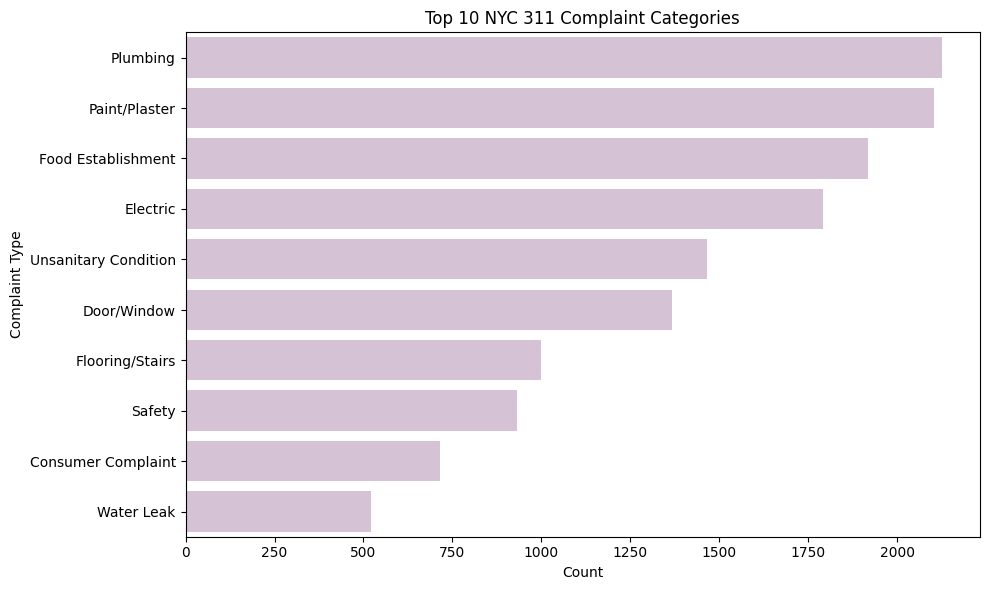

In [ ]:
top_complaints = df['Complaint Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_complaints.values, y=top_complaints.index, color='#d8bfd8')

plt.title('Top 10 NYC 311 Complaint Categories')
plt.xlabel('Count')
plt.ylabel('Complaint Type')
plt.tight_layout()

plt.savefig('top_10_complaint_categories.png', dpi=300)
plt.show()

Plumbing and Paint/Plaster categories accounted for nearly 18% of all complaint categories in the dataset, indicating that housing maintenance concerns are highly represented.

In [76]:
top_agencies = df['Agency'].value_counts().head(10)

top_agencies

,count
Agency,
Department of Housing Preservation and Development,12102
Department of Health and Mental Hygiene,4728
Department of Finance,1644
Department of Parks and Recreation,1168
Department of Transportation,1066
Department of Consumer Affairs,716
Taxi and Limousine Commission,588
Department of Sanitation,556
New York City Police Department,516


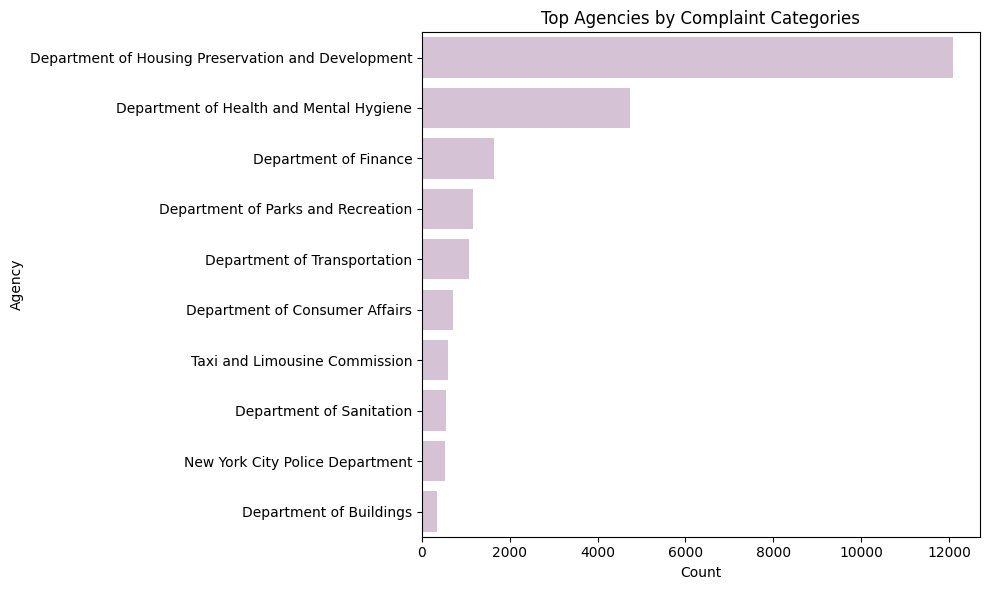

In [ ]:
top_agencies = df['Agency'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_agencies.values, y=top_agencies.index, color='#d8bfd8')

plt.title('Top Agencies by Complaint Categories')
plt.xlabel('Count')
plt.ylabel('Agency')
plt.tight_layout()

plt.savefig('top_agencies.png', dpi=300)
plt.show()

HPD represented approximately half of all complaint category records, indicating that housing related concerns make up a substantial portion of the complaint categories included in this dataset.

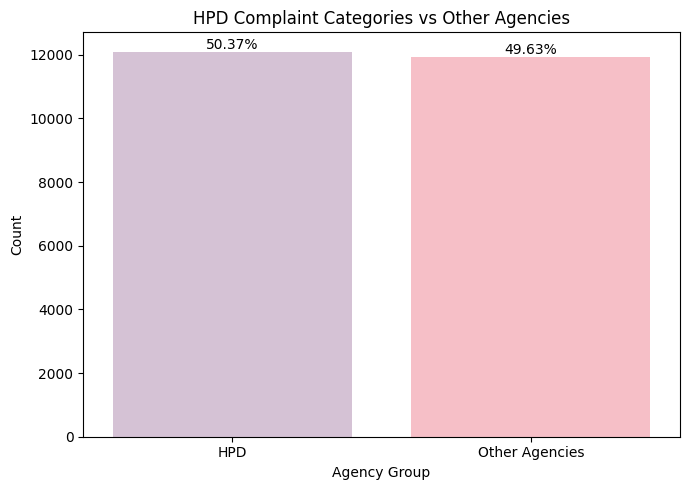

In [ ]:
df_temp = df.copy()
df_temp['Agency Group'] = df_temp['Agency'].apply(
    lambda x: 'HPD' if str(x).upper() == 'DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT' else 'Other Agencies'
)

agency_group_counts = df_temp['Agency Group'].value_counts().reset_index()
agency_group_counts.columns = ['Agency Group', 'Count']

agency_group_counts['Percentage'] = (
    agency_group_counts['Count'] / agency_group_counts['Count'].sum() * 100
).round(2)

plt.figure(figsize=(7,5))

colors = ['#d8bfd8', '#ffb6c1']

sns.barplot(
    data=agency_group_counts,
    x='Agency Group',
    y='Count',
    hue='Agency Group',
    palette=colors,
    legend=False
)

plt.title('HPD Complaint Categories vs Other Agencies')
plt.xlabel('Agency Group')
plt.ylabel('Count')

for index, row in agency_group_counts.iterrows():
    plt.text(index, row['Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.tight_layout()

plt.savefig('hpd_vs_other_agencies.png', dpi=300)
plt.show()

From the bar plot, we can observe that **HPD (Department of Housing Preservation and Development)** accounts for approximately **50.37%** of the complaints, while **Other Agencies** collectively account for approximately **49.63%** of the complaints. This indicates that HPD related complaint categories account for a slightly larger share of the records analyzed than all other agencies combined.

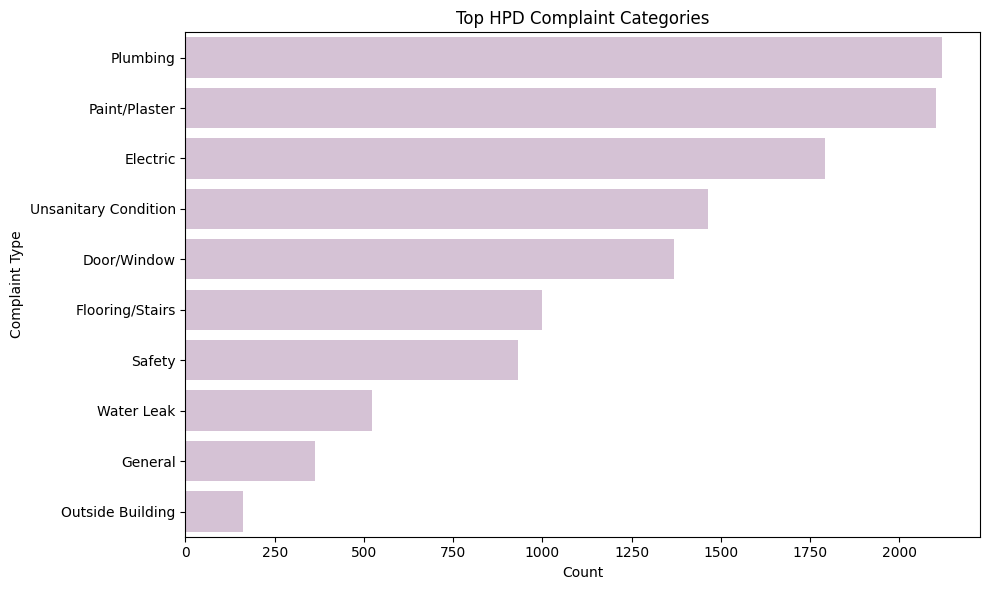

In [ ]:
df['Agency Group'] = df['Agency'].apply(
    lambda x: 'HPD' if str(x).upper() == 'DEPARTMENT OF HOUSING PRESERVATION AND DEVELOPMENT' else 'Other Agencies'
)

hpd_df = df[df['Agency Group'] == 'HPD']

top_hpd_complaints = hpd_df['Complaint Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_hpd_complaints.values, y=top_hpd_complaints.index, color='#d8bfd8')

plt.title('Top HPD Complaint Categories')
plt.xlabel('Count')
plt.ylabel('Complaint Type')
plt.tight_layout()

plt.savefig('top_hpd_complaint_categories.png', dpi=300)
plt.show()

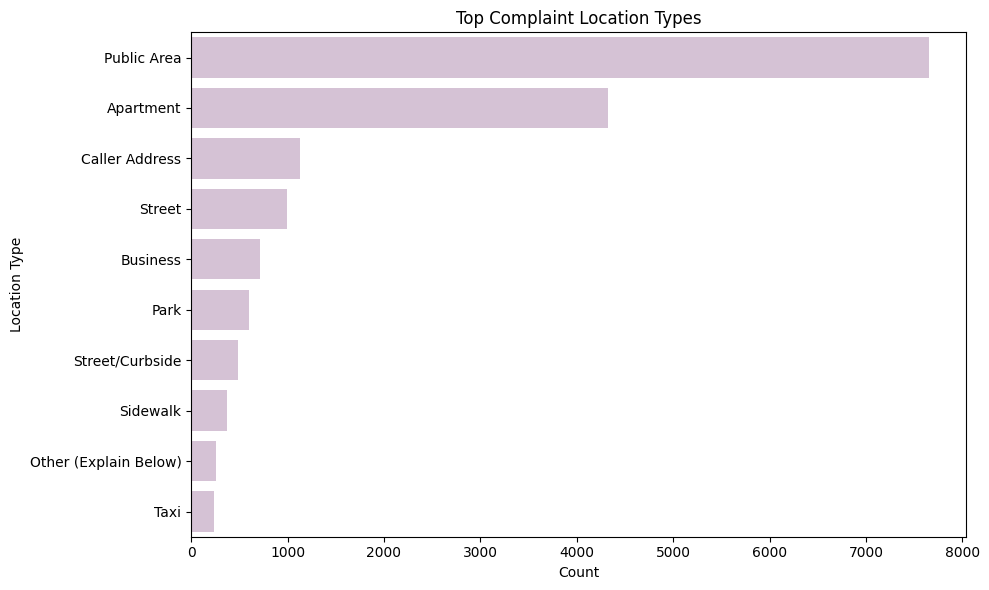

In [ ]:
top_locations = df['Location_Type'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values, y=top_locations.index, color='#d8bfd8')

plt.title('Top Complaint Location Types')
plt.xlabel('Count')
plt.ylabel('Location Type')
plt.tight_layout()

plt.savefig('top_location_types.png', dpi=300)
plt.show()

Public Areas and Apartments were the most common locations associated with complaint categories, highlighting both residential and community-based concerns.

#Conclusion

These findings suggest that housing related concerns remain a significant concern for New Yorkers and represent a large portion of the complaint categories reported through the NYC 311 system.